# The stochastic O&M tool for down side risk in TIMES

## How to use
In your environment run 'pip install -e' to install the packages and dependensies

Then having the 'offshore_om' package you can import the nesessary functions and start.

In [25]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

import offshore_om as om 

In [29]:
import importlib

importlib.reload(om)  # Reload the OM pacage to ensure the latest changes are reflected in the notebook

<module 'offshore_om' from 'C:\\Users\\IFE13253\\OneDrive - Institutt for Energiteknikk\\Documents\\offshore-wind-om\\src\\offshore_om\\__init__.py'>

With the right depensesie intialise and cofigure your senario as you want with the right sensetivities and data
## Path configurations

In [30]:
# Root folder for the project. Update this if your workspace moves.
ROOT_DIR = Path(
    "C:/Users/IFE13253/OneDrive - Institutt for Energiteknikk/Documents/offshore-wind-om"
)

#Input and output folders
TIMES_INPUT_DIR = ROOT_DIR / "times-input"
OUTPUT_DIR = ROOT_DIR / "model-results"

Having cofigured the main paths you can configure the scenarios and the corresponding files from the input
## Scenario configuration
Her is an exemple with the inc and tech scenarios

In [31]:
# Scenario definitions for the master simulation.
# The Master script will read these files and optionally use market prices.
SCENARIO_CONFIGS = [
    {
        "Scenario": "TECH market",
        "MarketFile": TIMES_INPUT_DIR / "tech" / "tech onshore shadow price.csv",
        "production_folder": TIMES_INPUT_DIR / "tech",
        "market_price_file": TIMES_INPUT_DIR / "tech" / "tech_price.csv",
        "capacity_file": TIMES_INPUT_DIR / "tech" / "tech_capacity.csv",
    },
    {
        "Scenario": "INC market",
        "MarketFile": TIMES_INPUT_DIR / "inc" / "inc onshore shadow price.csv",
        "production_folder": TIMES_INPUT_DIR / "inc",
        "market_price_file": TIMES_INPUT_DIR / "inc" / "inc_price.csv",
        "capacity_file": TIMES_INPUT_DIR / "inc" / "inc_capacity.csv",
    },
]

In [32]:
# TIMES subsidy input and output configuration.
# This config only contains folder/file locations and mappings.
# Discount rates and base year are global and are not set here.
TIMES_SUBSIDY_CONFIG = {
    "region_price_map": {
        "O_Sorvest": "NO2",
        "O_Vestavind2": "NO2",
        "O_Nordvest": "NO3",
        "O_Nordavind": "NO4",
        "O_Vestavind1": "NO5",
    },
    "file_pattern": "*.csv",
    "process_filter": None,
}

Having the different scenarios you want to model import the sensitivities
## Sensetivity lists

In [33]:
# Sensitivity lists to sweep in the master simulation.
DISCOUNT_RATE_LIST = [0.06]  # e.g. [0.06, 0.07, 0.08]
TURBINE_CAPACITY_LIST = [15]  # e.g. [12, 15, 17, 20]
N_TURBINES_LIST = [100] #[1, 5, 10, 20, 35, 50, 75, 100]
HORIZON_YEARS = [25.0]  # e.g. [20.0, 25.0, 30.0]
FAILURE_RATE_TYPES = ["hendriks"]  # e.g. ["carrol", "hendriks"]
SUBSIDY_PRICE_LIST = [115]

base_year = 2030

total_runs = (len(DISCOUNT_RATE_LIST) * len(TURBINE_CAPACITY_LIST) * len(N_TURBINES_LIST) * len(HORIZON_YEARS) * len(FAILURE_RATE_TYPES) * len(SUBSIDY_PRICE_LIST) * len(SCENARIO_CONFIGS))

print(total_runs)

2


## Master table execution
Excecution of the montecarlo simulation and financial logic excecuted for all the sensitivites etc

Simulating for region: Nordavind

Completed simulation 1/1000
Campaigns: 85
Repairs: 194

Completed simulation 1000/1000
Campaigns: 86
Repairs: 178

SIMULATION SUMMARY
Mean Campaigns: 83.788
Mean direct cost: 13915489.155891903
Mean lost MWh: 2887850.6619871347
Installed capacity: 1500
Mean downtime per turbine: 3897.234361656052

AVERAGE REPAIRS PER TURBINE OVER HORIZON
Blades    1.284 repairs/lifetime
Gearbox   0.488 repairs/lifetime
Generator 0.070 repairs/lifetime
Runnig discount rate 0.06
Figure exported to: C:\Users\IFE13253\OneDrive - Institutt for Energiteknikk\Documents\offshore-wind-om\notebooks\figures\cumulative_direct_cost_risk_evolution_Nordavind.pdf
Figure exported to: C:\Users\IFE13253\OneDrive - Institutt for Energiteknikk\Documents\offshore-wind-om\notebooks\figures\hist_direct_cost_distribution_Nordavind.pdf
Simulating for region: Nordvest

Completed simulation 1/1000
Campaigns: 92
Repairs: 195

Completed simulation 1000/1000
Campaigns: 89
Repairs: 192

SIMULATION SU

C:\Users\IFE13253\OneDrive - Institutt for Energiteknikk\Documents\offshore-wind-om\src\offshore_om\plotting.py:247: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(9, 5.5))


Figure exported to: C:\Users\IFE13253\OneDrive - Institutt for Energiteknikk\Documents\offshore-wind-om\notebooks\figures\cumulative_direct_cost_risk_evolution_Sonnavind.pdf
Figure exported to: C:\Users\IFE13253\OneDrive - Institutt for Energiteknikk\Documents\offshore-wind-om\notebooks\figures\hist_direct_cost_distribution_Sonnavind.pdf


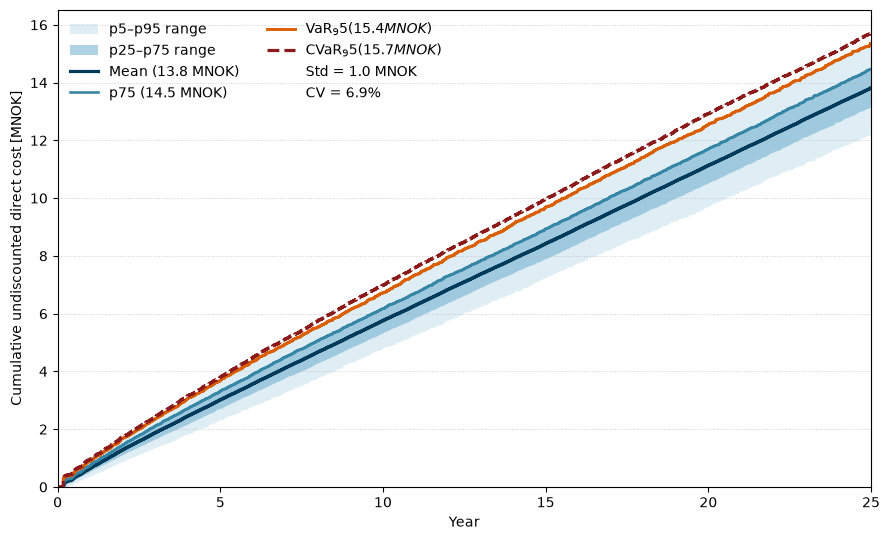

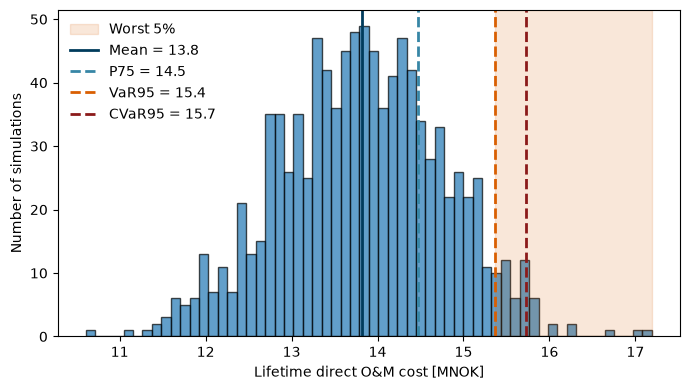

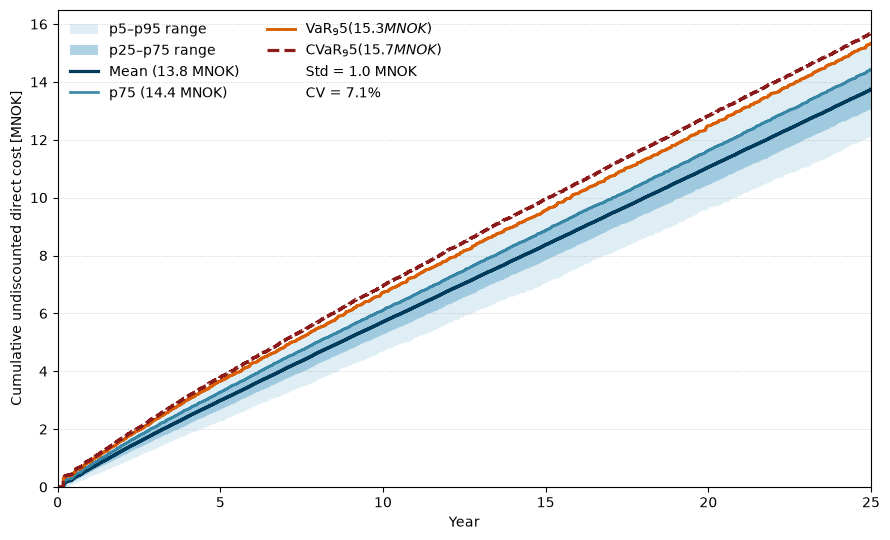

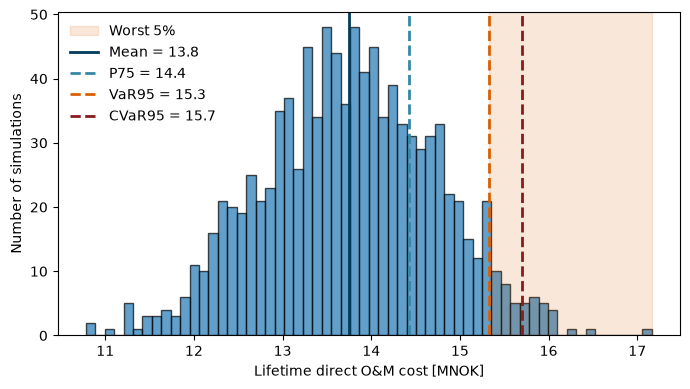

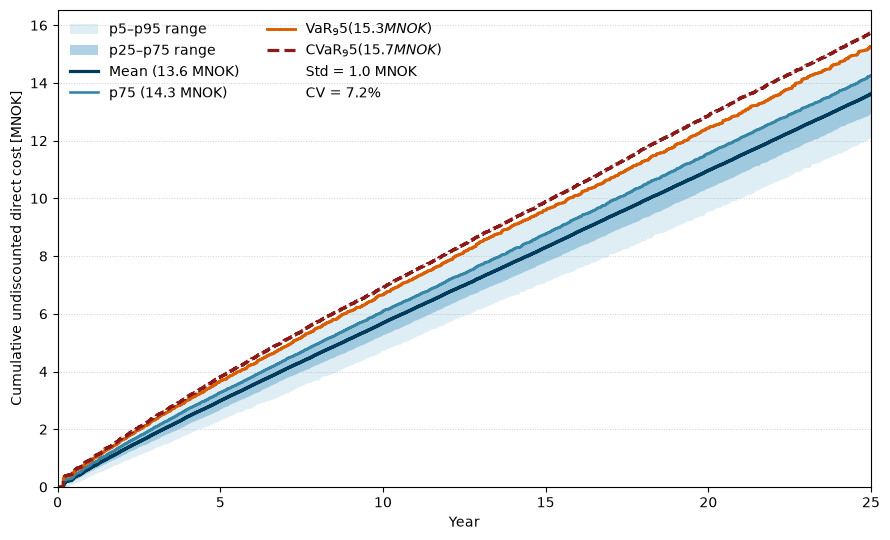

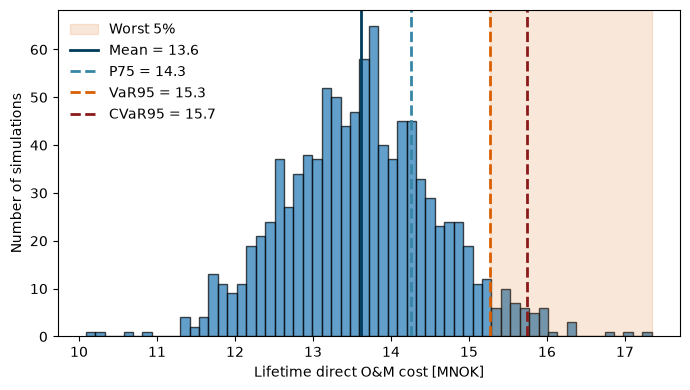

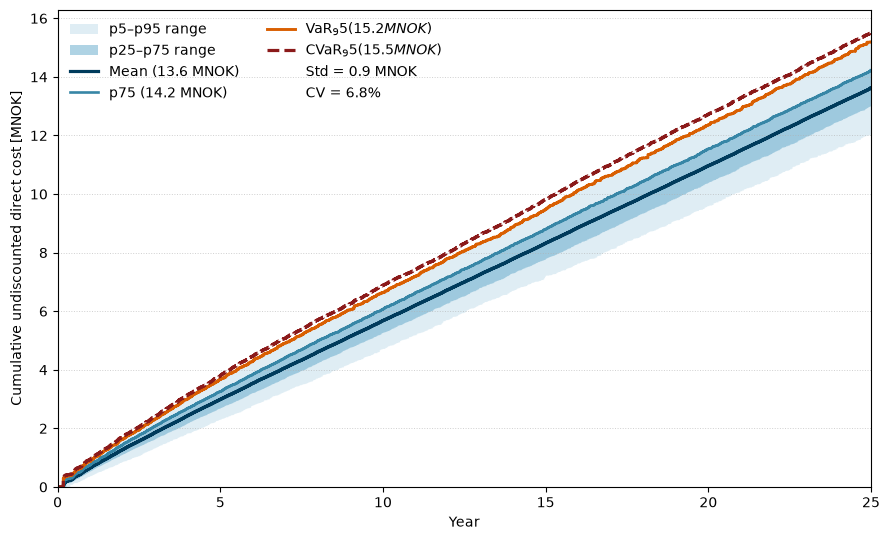

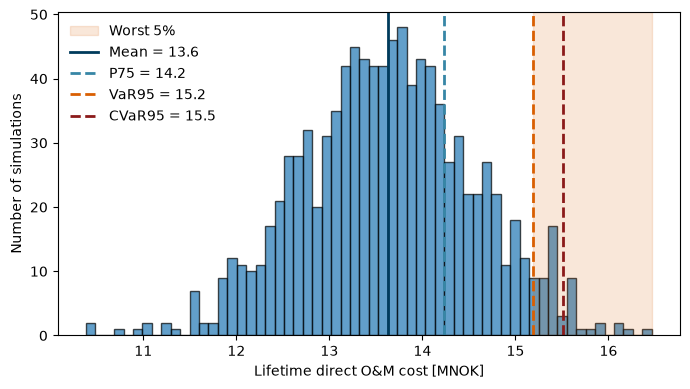

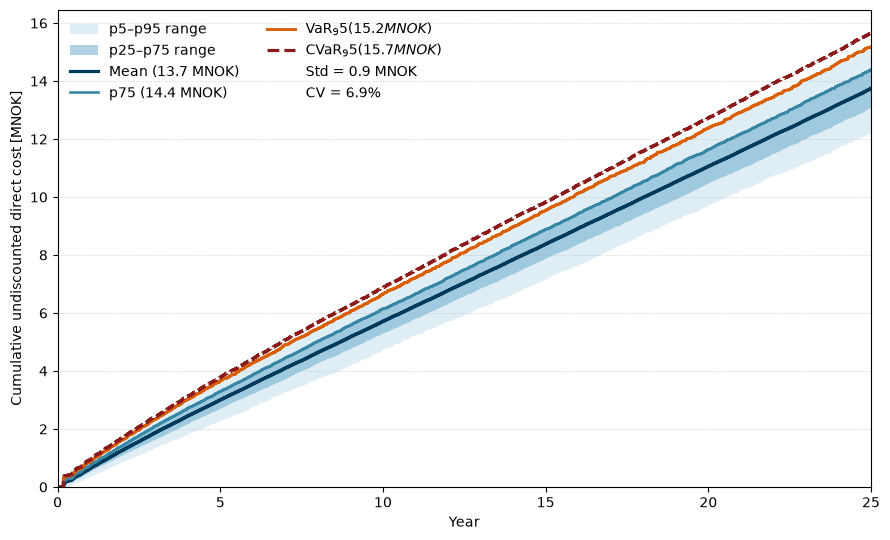

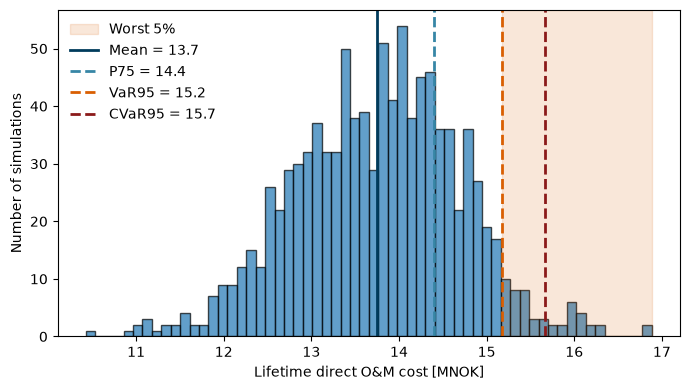

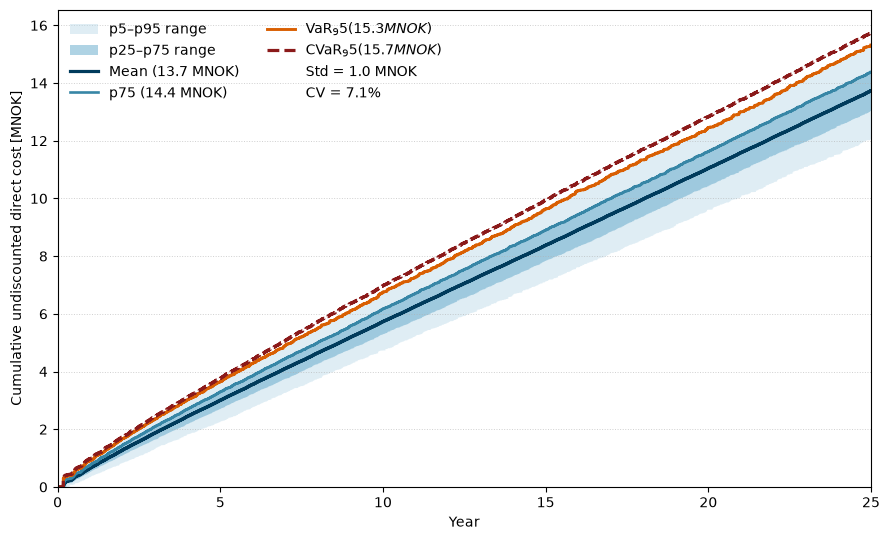

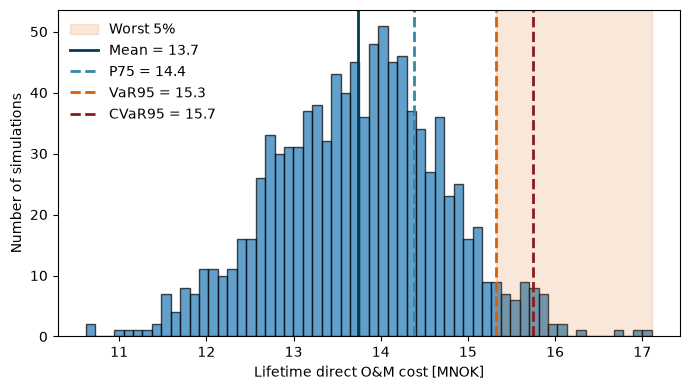

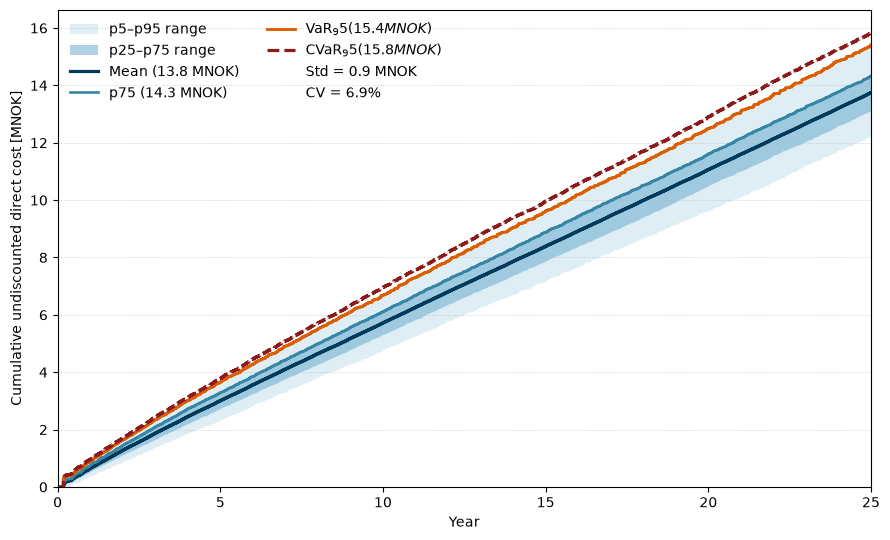

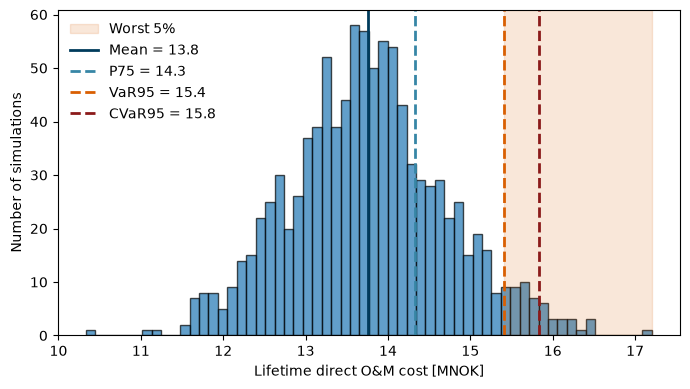

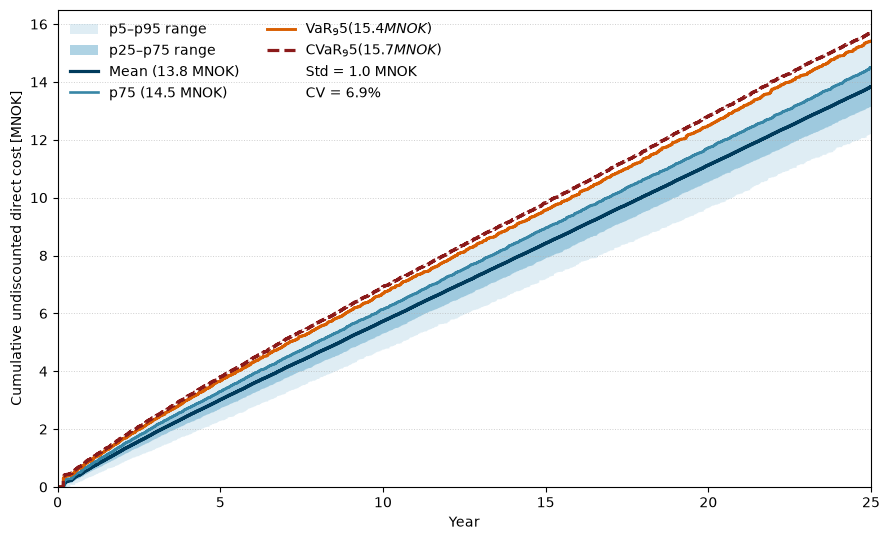

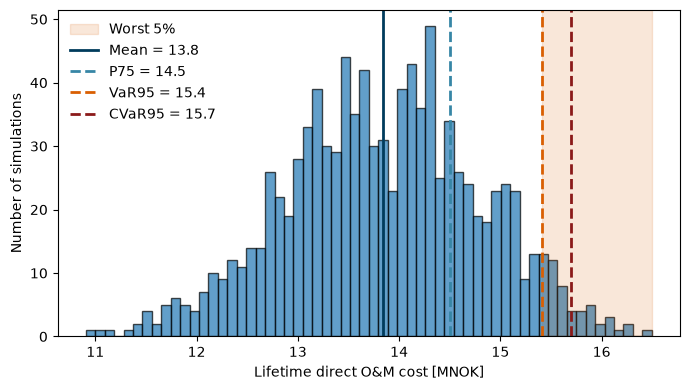

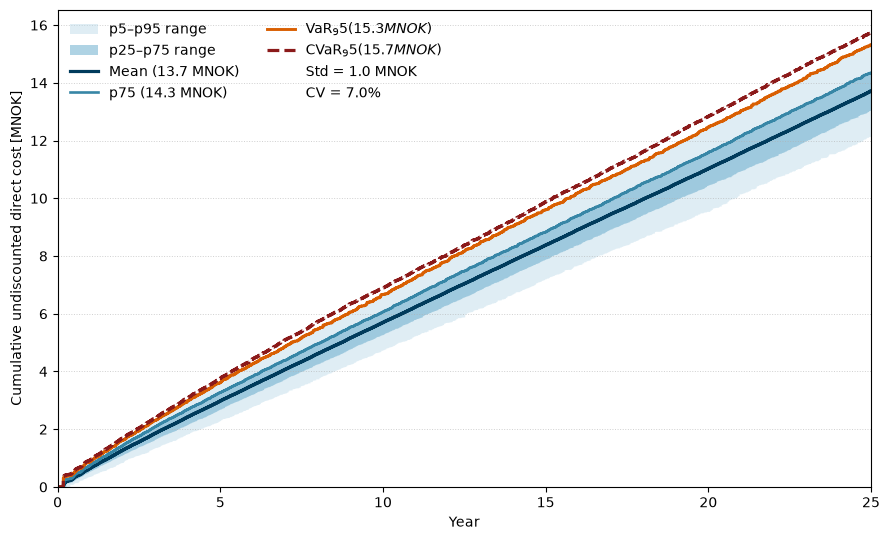

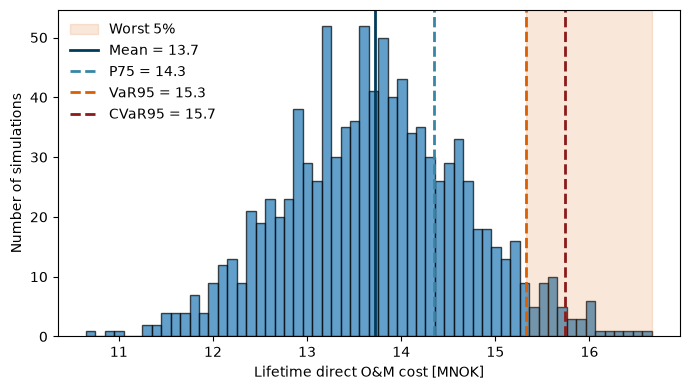

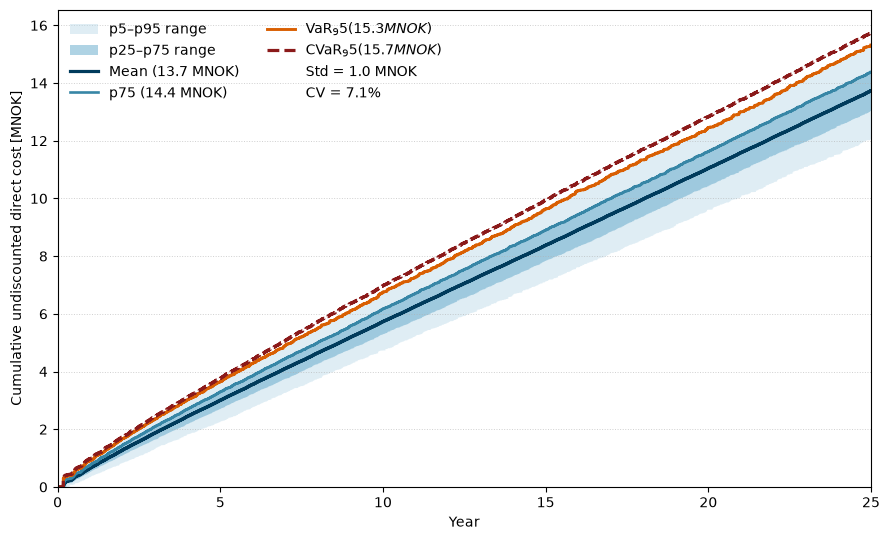

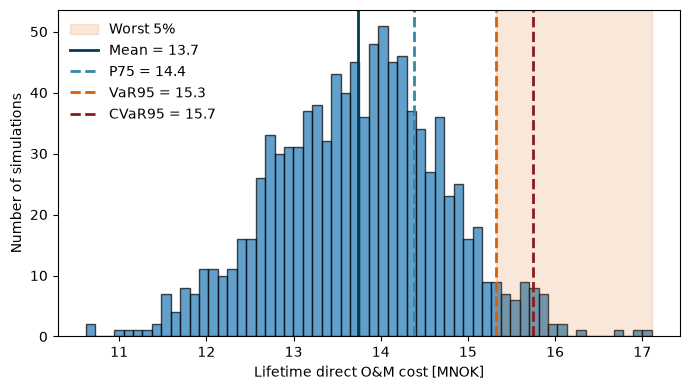

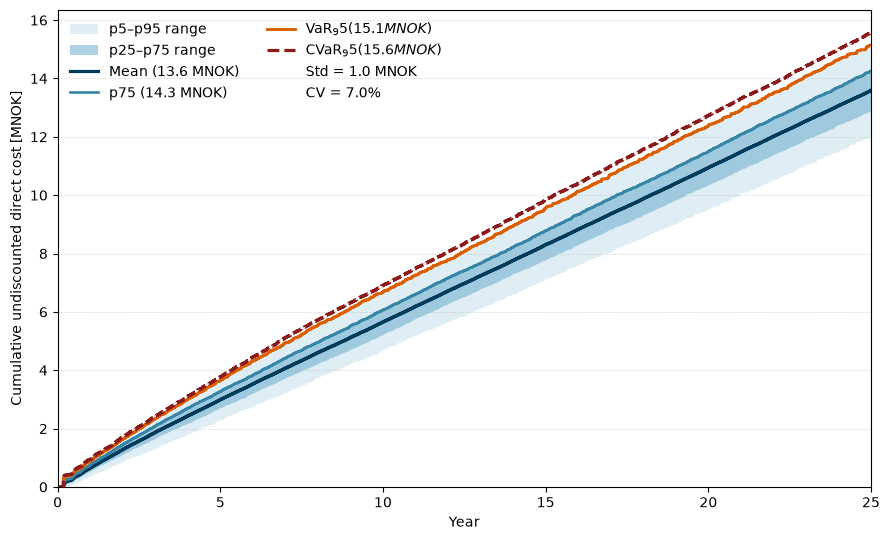

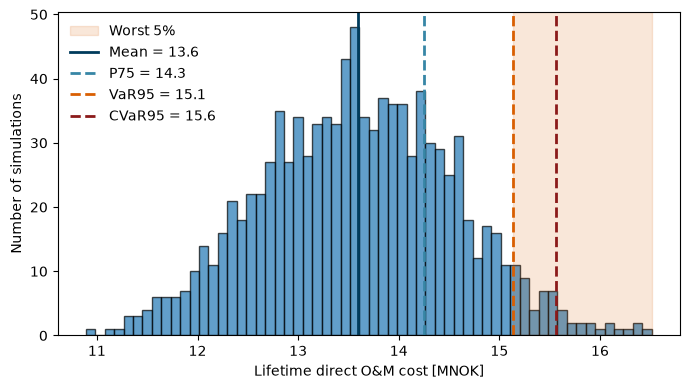

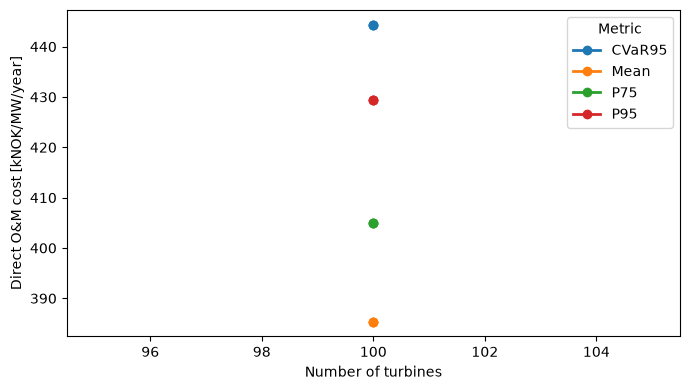

In [34]:
master_df = om.run_master(
    scenario_configs=om.load_scenario_configs(SCENARIO_CONFIGS),
    turbine_capacity_list=TURBINE_CAPACITY_LIST,
    n_turbines_list=N_TURBINES_LIST,
    discount_rate_list=DISCOUNT_RATE_LIST,
    horizon_years=HORIZON_YEARS,
    failure_rate_types=FAILURE_RATE_TYPES,
    subsidy_price_list=SUBSIDY_PRICE_LIST,
    output_dir=OUTPUT_DIR,
)



## TIMES subsidy representation
This is the output to represent subsidy gains in TIMES

In [ ]:
times_capex_df = om.run_subsidy_capex(
    times_subsidy_config=TIMES_SUBSIDY_CONFIG,
    discount_rate_list=DISCOUNT_RATE_LIST,
    subsidy_price_list=SUBSIDY_PRICE_LIST,
    times_scenario=SCENARIO_CONFIGS,
    base_year = base_year,
    output_dir=OUTPUT_DIR,
)

# Additional times input graph


----------------
Nordavind
           Site  Metric  DiscountRate  ParkSize  TurbineCapacity  \
1444  Nordavind    Mean          0.06       100               15   
1445  Nordavind     P75          0.06       100               15   
1446  Nordavind     P95          0.06       100               15   
1447  Nordavind  CVaR95          0.06       100               15   

     FailureRateType    Scenario  
1444        hendriks  INC market  
1445        hendriks  INC market  
1446        hendriks  INC market  
1447        hendriks  INC market  

Duplicates:
Metric
Mean      1
P75       1
P95       1
CVaR95    1
dtype: int64

----------------
SorvestF
          Site  Metric  DiscountRate  ParkSize  TurbineCapacity  \
2020  SorvestF    Mean          0.06       100               15   
2021  SorvestF     P75          0.06       100               15   
2022  SorvestF     P95          0.06       100               15   
2023  SorvestF  CVaR95          0.06       100               15   

     Failure

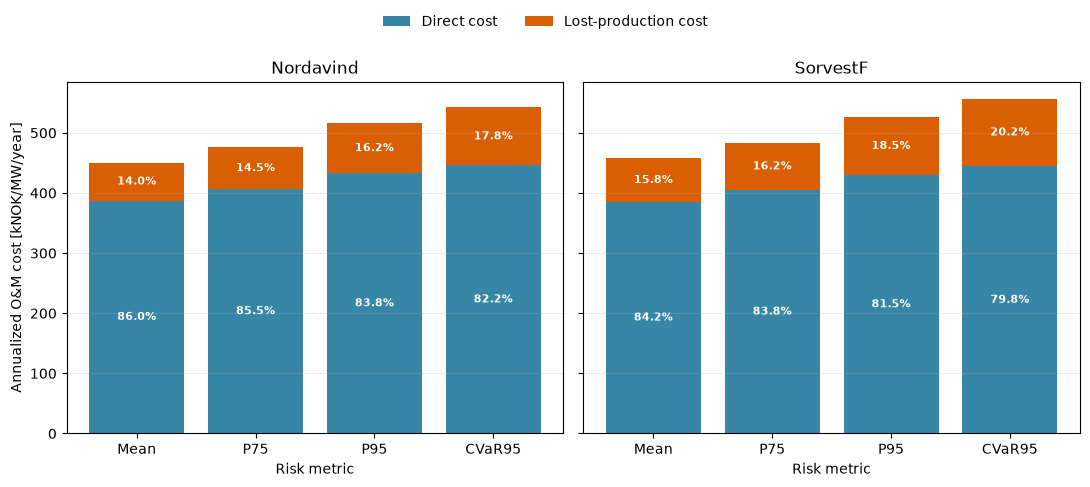

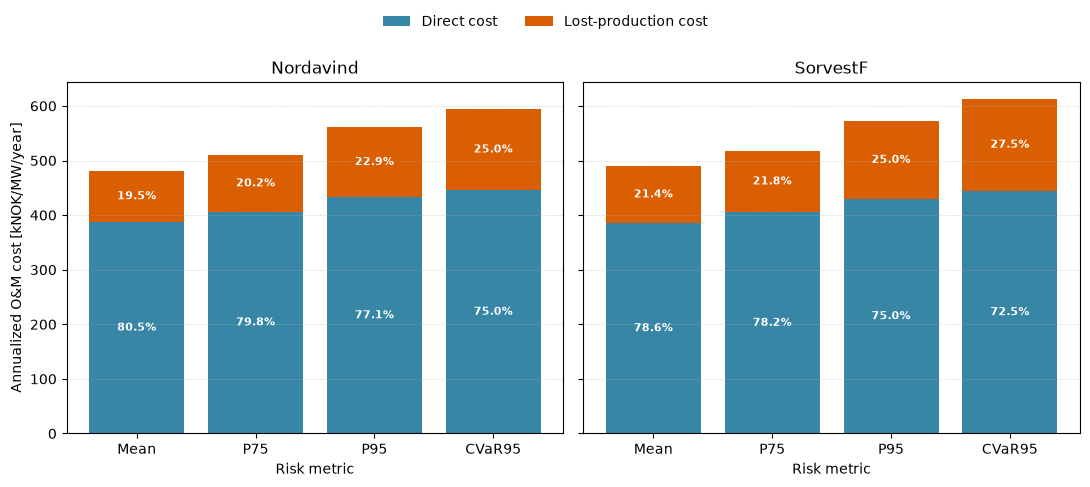

In [ ]:
master_df = pd.read_excel(
    "../times-input/masterdata.xlsx",
    engine="openpyxl",
)
scenarios = ["INC market", "Subsidy_115"]

for scenario in scenarios:
    fig, axes = om.plot_cost_composition(
        master_df=master_df,
        output_name=scenario,
        scenario=scenario,
    )


Figure exported to: C:\Users\IFE13253\OneDrive - Institutt for Energiteknikk\Documents\offshore-wind-om\notebooks\figures\direct_cost_vs_farm_size_metrics.pdf


(<Figure size 700x400 with 1 Axes>,
 <Axes: xlabel='Number of turbines', ylabel='Direct O&M cost [kNOK/MW/year]'>)

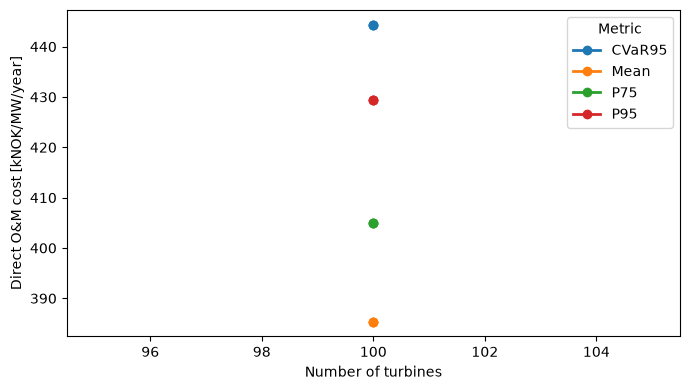

In [35]:
om.plot_direct_cost_vs_farm_size(
    master_df=master_df)

Figure exported to: C:\Users\IFE13253\OneDrive - Institutt for Energiteknikk\Documents\offshore-wind-om\notebooks\figures\availability_loss_figure.pdf


(<Figure size 1000x450 with 2 Axes>,
 array([<Axes: title={'center': 'Nordavind'}, xlabel='Risk metric', ylabel='Availability change relative to mean [%]'>,
        <Axes: title={'center': 'SorvestF'}, xlabel='Risk metric'>],
       dtype=object))

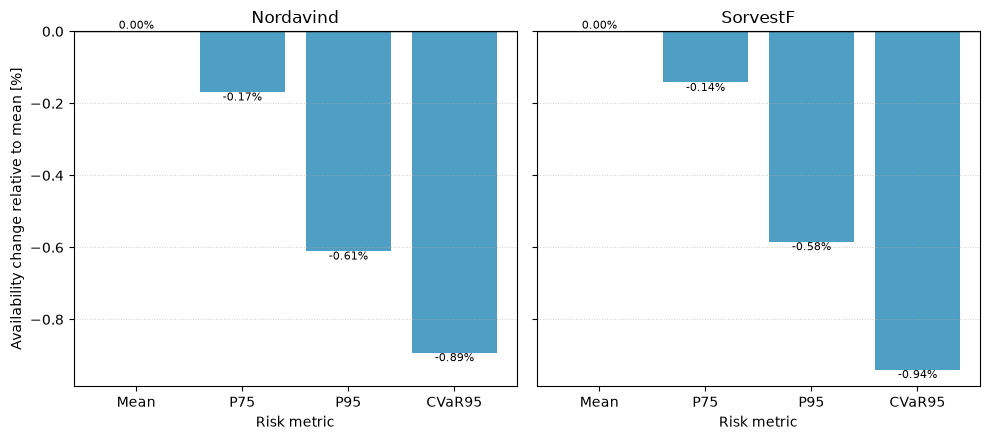

In [9]:
om.plot_availability_loss(
    master_df=master_df,
    output_name="figure",
)

Figure exported to: C:\Users\IFE13253\OneDrive - Institutt for Energiteknikk\Documents\offshore-wind-om\notebooks\figures\availability_translation_days.pdf


(<Figure size 1000x450 with 2 Axes>,
 array([<Axes: title={'center': 'Nordavind'}, xlabel='Risk metric', ylabel='Downtime [days/year]'>,
        <Axes: title={'center': 'SorvestF'}, xlabel='Risk metric'>],
       dtype=object))

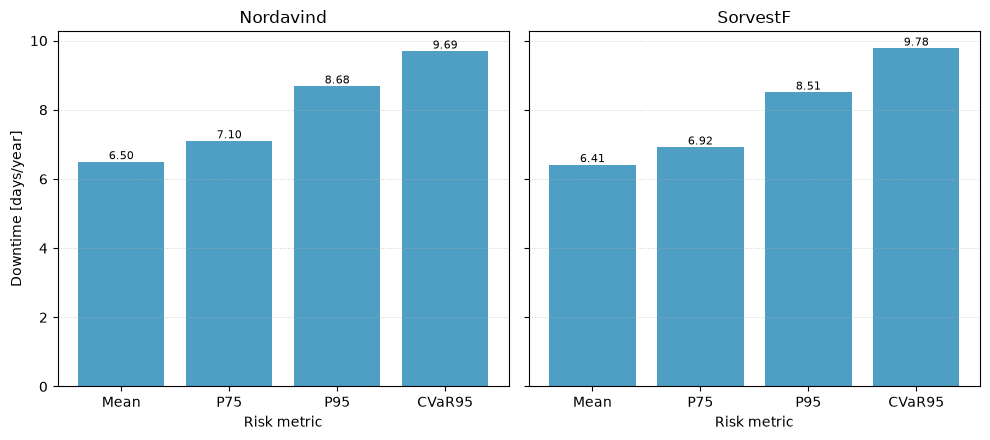

In [ ]:
om.plot_availability_translation(
    master_df=master_df,
    output_name="days",
)